## Analisis Penggunaan Preprocessing dan Ekstraksi Fitur GLCM

Pada tahap awal pengolahan citra digital, proses preprocessing memegang peranan krusial dalam menentukan kualitas fitur tekstur yang akan diekstraksi oleh Gray Level Co-occurrence Matrix (GLCM). Sebelumnya, tahapan preprocessing yang digunakan melibatkan serangkaian filter morfologi dan deteksi tepi yang cukup panjang, yakni meliputi Grayscale, Resize, Histogram Equalization, CLAHE, Thresholding, Sharpening, Sobel Edge Detection, hingga Morphological Closing. 

Meskipun tahapan tersebut terlihat komprehensif, kombinasi proses tersebut terbukti kurang optimal untuk metode GLCM. Penggunaan operasi biner seperti Thresholding dan Sobel Edge Detection secara fundamental merusak informasi spasial antarpiksel karena mengubah citra menjadi nilai ekstrem hitam dan putih (garis tepi). Hal ini menghilangkan gradien tekstur alami pada daun yang justru sangat dibutuhkan oleh matriks GLCM untuk menghitung metrik tekstur seperti Contrast, Energy, dan Homogeneity. Lebih lanjut, proses Morphological Closing cenderung menutup celah atau bercak alami pada daun sehingga membentuk blok-blok piksel buatan yang mendistorsi tekstur penyakit yang sebenarnya. Selain itu, penggunaan Histogram Equalization yang ditumpuk dengan CLAHE seringkali menyebabkan intensitas citra menjadi terlalu kontras (over-amplified), menutupi detail halus yang esensial.

Sebagai solusi dan pengembangan dari pendekatan sebelumnya, alur preprocessing kini disederhanakan dengan mengadaptasi metode yang terbukti lebih efektif, yaitu Grayscale, Resize, Gaussian Blur, CLAHE, dan Sharpening. Pada pendekatan ini, Gaussian Blur digunakan secara strategis pada tahap awal untuk meredam noise sensor yang mengganggu tanpa merusak tepi objek. Setelah noise dihilangkan, metode CLAHE diaplikasikan untuk meningkatkan kontras lokal secara adaptif sehingga memperjelas alur dan tekstur penyakit secara natural. Terakhir, Sharpening diterapkan untuk mempertegas batas tekstur daun yang sudah dibersihkan. 

Pendekatan baru ini memastikan bahwa citra yang masuk ke tahap ekstraksi fitur tetap mempertahankan karakteristik tekstur aslinya secara utuh dengan tingkat kejelasan yang jauh lebih tinggi. Dengan tekstur citra yang presisi dan tidak mendistorsi objek asli, ekstraksi GLCM mampu menangkap hubungan spasial antarpiksel dengan sangat baik sehingga menghasilkan sekumpulan fitur tekstur yang jauh lebih representatif untuk melatih model Random Forest, SVM, maupun KNN pada tahapan klasifikasi selanjutnya.

In [1]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
import seaborn as sns

In [2]:
data = []
labels = []
file_name = []
IMG_SIZE = (256, 256)

for sub_folder in os.listdir("Assets/"):
    sub_folder_files = os.listdir(os.path.join("Assets/", sub_folder))
    for i, filename in enumerate(sub_folder_files):
        img_path = os.path.join("Assets/", sub_folder, filename)
        img = cv.imread(img_path)

        # Check if image is loaded successfully
        if img is None:
            print(f"Warning: Could not load image {img_path}. Skipping.")
            continue

        img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
        img = cv.resize(img, IMG_SIZE) # Resize the image to a consistent size
        img = img.astype(np.uint8)

        data.append(img)
        labels.append(sub_folder)
        name = os.path.splitext(filename)[0]
        file_name.append(filename)

data = np.array(data)
labels = np.array(labels)

In [3]:
def clahe(img, clip_limit=2.0, grid_size=(8,8)):
    h, w = img.shape
    gh, gw = grid_size

    tile_h = h // gh
    tile_w = w // gw

    output = np.zeros_like(img, dtype=np.uint8)

    for i in range(gh):
        for j in range(gw):

            x1 = i * tile_h
            x2 = (i + 1) * tile_h if i != gh - 1 else h
            y1 = j * tile_w
            y2 = (j + 1) * tile_w if j != gw - 1 else w

            tile = img[x1:x2, y1:y2]

            # histogram
            hist, bins = np.histogram(tile.flatten(), 256, [0,256])

            # clip limit
            limit = clip_limit * tile.size / 256
            excess = hist - limit
            excess[excess < 0] = 0
            hist = np.minimum(hist, limit)

            # redistribusi excess
            hist += int(excess.sum() / 256)

            # CDF
            cdf = hist.cumsum()
            cdf = (cdf - cdf.min()) * 255 / (cdf.max() - cdf.min() + 1e-5)

            # mapping pixel
            tile_eq = np.interp(tile.flatten(), bins[:-1], cdf)
            tile_eq = tile_eq.reshape(tile.shape)

            output[x1:x2, y1:y2] = tile_eq

    return output.astype(np.uint8)

def convolve2d(image_channel, kernel):
    img_h, img_w = image_channel.shape
    kernel_h, kernel_w = kernel.shape
    pad_h = kernel_h // 2
    pad_w = kernel_w // 2
    padded_image = np.pad(image_channel, ((pad_h, pad_h), (pad_w, pad_w)), mode='edge')
    output = np.zeros_like(image_channel, dtype=np.float32)
    for i in range(img_h):
        for j in range(img_w):
            region = padded_image[i:i+kernel_h, j:j+kernel_w]
            output[i, j] = np.sum(region * kernel)
    return np.clip(output, 0, 255).astype(np.uint8)

def apply_kernel(image, kernel):
    if len(image.shape) == 3:
        output = np.zeros_like(image)
        for c in range(image.shape[2]):
            output[:, :, c] = convolve2d(image[:, :, c], kernel)
        return output
    else:
        return convolve2d(image, kernel)

def sharpening(image):
    kernel_sharpen = np.array([
        [ 0, -1,  0],
        [-1,  5, -1],
        [ 0, -1,  0]
    ], dtype=np.float32)
    return apply_kernel(image, kernel_sharpen)

def gaussian_blur(image):
    kernel_gaussian = np.array([
        [1, 2, 1],
        [2, 4, 2],
        [1, 2, 1]
    ], dtype=np.float32) / 16.0
    return apply_kernel(image, kernel_gaussian)


## Preprocessing Citra Lanjutan

Proses prapemrosesan memegang peranan vital dalam memastikan kualitas fitur yang akan diekstrak. Pada tahap ini, citra RGB asli ditransformasikan ke dalam representasi skala keabuan (*grayscale*) guna memusatkan fokus ekstraksi pada variansi intensitas cahaya alih-alih gradasi warna. Mengingat variasi ukuran gambar asli, reduksi resolusi (*resizing*) menjadi 256x256 piksel dilakukan untuk menstandarisasi matriks input. Selanjutnya, Gaussian Blur diaplikasikan secara hati-hati untuk mereduksi *noise* berfrekuensi tinggi tanpa meredam tepi objek. Setelah citra bersih dari derau, metode *Contrast Limited Adaptive Histogram Equalization* (CLAHE) diterapkan guna mengelevasi rentang dinamis citra secara lokal, yang secara signifikan memperjelas corak penyakit. Proses ini kemudian diakhiri dengan *Sharpening* yang bertugas mempertegas batas-batas spasial citra yang kini telah optimal.

In [4]:
# Menggunakan kombinasi Gaussian Blur -> CLAHE -> Sharpening
dataPreprocessed = []
for i in range(len(data)): # Loop through each image and do preprocessing
    # 1. Denoising dengan Gaussian Blur
    img_blur = gaussian_blur(data[i])
    # 2. Peningkatan Kontras dengan CLAHE
    img_clahe = clahe(img_blur)
    # 3. Penajaman tekstur dengan Sharpening
    img_sharp = sharpening(img_clahe)
    # Pastikan tipe datanya uint8 agar skimage tidak error
    img_sharp = img_sharp.astype(np.uint8)
    dataPreprocessed.append(img_sharp)

dataPreprocessed = np.array(dataPreprocessed)

## Definisi Fungsi Gray Level Co-occurrence Matrix (GLCM)

Setelah citra mencapai kualitas optimal, tahapan krusial berikutnya adalah merumuskan infrastruktur komputasional untuk ekstraksi fitur tekstur. Gray Level Co-occurrence Matrix (GLCM) dipilih sebagai metode utama karena kemampuannya yang luar biasa dalam memetakan probabilitas transisi derajat keabuan antarpiksel tetangga. Pada blok instruksi ini, matriks kookurensi dirancang untuk dikalkulasi pada empat orientasi sudut spasial utama, yakni $0^\circ$ (horizontal), $45^\circ$ (diagonal kanan atas), $90^\circ$ (vertikal), dan $135^\circ$ (diagonal kiri atas). Selanjutnya, tujuh parameter statistik orde dua didefinisikan untuk merepresentasikan properti tekstur secara komprehensif, mencakup *Correlation, Dissimilarity, Homogeneity, Contrast, Angular Second Moment (ASM), Energy*, dan *Entropy*.

In [5]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. It should be one of the following: 0, 45, 90, 135.")

    # mengembalikan matrix glcm dari image
    glcm = graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)
    return glcm

In [6]:
def correlation(matriks):
	return graycoprops(matriks, 'correlation')[0, 0]

def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def entropyGlcm(matriks):
    return entropy(matriks.ravel())

## Perhitungan Matriks GLCM Multidireksional

Menyadari bahwa pola bercak penyakit pada daun mangga memiliki orientasi spasial yang tidak menentu, penarikan fitur tidak dapat dibatasi pada satu arah tunggal. Oleh karenanya, matriks probabilitas spasial GLCM dikomputasi secara independen untuk keempat arah sudut yang telah ditetapkan sebelumnya. Eksekusi proses ini memastikan bahwa setiap matriks yang terbentuk memiliki invarian terhadap rotasi gambar, di mana sistem dapat menangkap karakteristik penyebaran penyakit yang menjalar secara vertikal maupun horizontal dengan tingkat presisi yang identik.

In [7]:
Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []

dataPreprocessed = dataPreprocessed.astype(np.uint8) # Convert the entire array to uint8 once

for i in range(len(dataPreprocessed)):
    # dataPreprocessed[i] = dataPreprocessed[i].astype(np.uint8) # This line is no longer needed after converting the entire array
    D0 = glcm(dataPreprocessed[i], 0)
    D45 = glcm(dataPreprocessed[i], 45)
    D90 = glcm(dataPreprocessed[i], 90)
    D135 = glcm(dataPreprocessed[i], 135)
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)

## Inisialisasi Ruang Fitur

Untuk mengakomodasi kompleksitas data hasil ekstraksi, sebuah ruang fitur (*feature space*) virtual perlu dipersiapkan. Deklarasi array kosong dilakukan secara terstruktur untuk menampung masing-masing dari tujuh metrik statistik GLCM yang dikalikan dengan empat sudut orientasi. Inisialisasi ini merupakan fondasi awal penyusunan matriks berdimensi tinggi yang nantinya akan memuat 28 atribut tekstur unik untuk setiap sampel citra, mempersiapkan data agar selaras dengan arsitektur algoritma *Machine Learning*.

In [8]:
Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 =  [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135 =  [], [], [], []
ASM0, ASM45, ASM90, ASM135 =  [], [], [], []
energy0, energy45, energy90, energy135 =  [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

In [9]:
for i in range(len(dataPreprocessed)):
    C0 = correlation(Derajat0[i])
    correlation0.append(C0)
    C45 = correlation(Derajat45[i])
    correlation45.append(C45)
    C90 = correlation(Derajat90[i])
    correlation90.append(C90)
    C135 = correlation(Derajat135[i])
    correlation135.append(C135)

for i in range(len(data)):
    K0 = contrast(Derajat0[i])
    K45 = contrast(Derajat45[i])
    K90 = contrast(Derajat90[i])
    K135 = contrast(Derajat135[i])
    Kontras0.append(K0)
    Kontras45.append(K45)
    Kontras90.append(K90)
    Kontras135.append(K135)

for i in range(len(data)):
    Dis0 = dissimilarity(Derajat0[i])
    Dis45 = dissimilarity(Derajat45[i])
    Dis90 = dissimilarity(Derajat90[i])
    Dis135 = dissimilarity(Derajat135[i])
    dissimilarity0.append(Dis0)
    dissimilarity45.append(Dis45)
    dissimilarity90.append(Dis90)
    dissimilarity135.append(Dis135)

for i in range(len(data)):
    H0 = homogenity(Derajat0[i])
    H45 = homogenity(Derajat45[i])
    H90 = homogenity(Derajat90[i])
    H135 = homogenity(Derajat135[i])
    homogenity0.append(H0)
    homogenity45.append(H45)
    homogenity90.append(H90)
    homogenity135.append(H135)

for i in range(len(data)):
    E0 = entropyGlcm(Derajat0[i])
    E45 = entropyGlcm(Derajat45[i])
    E90 = entropyGlcm(Derajat90[i])
    E135 = entropyGlcm(Derajat135[i])
    entropy0.append(E0)
    entropy45.append(E45)
    entropy90.append(E90)
    entropy135.append(E135)

for i in range(len(data)):
    A0 = ASM(Derajat0[i])
    A45 = ASM(Derajat45[i])
    A90 = ASM(Derajat90[i])
    A135 = ASM(Derajat135[i])
    ASM0.append(A0)
    ASM45.append(A45)
    ASM90.append(A90)
    ASM135.append(A135)

for i in range(len(data)):
    ER0 = energy(Derajat0[i])
    ER45 = energy(Derajat45[i])
    ER90 = energy(Derajat90[i])
    ER135 = energy(Derajat135[i])
    energy0.append(ER0)
    energy45.append(ER45)
    energy90.append(ER90)
    energy135.append(ER135)

## Tabulasi dan Persistensi Data Fitur

Kumpulan 28 atribut fitur spasial yang telah berhasil diekstraksi selanjutnya dikonsolidasikan secara rapi ke dalam bentuk *DataFrame Pandas*, bersanding dengan identitas berkas dan label kelas penyakit yang menjadi target prediksi. Bentuk tabular ini tidak hanya divisualisasikan untuk memvalidasi ketiadaan nilai kosong (*missing values*), namun juga langsung diekspor ke dalam wujud berkas *Comma Separated Values* (CSV). Tindakan persistensi data ini merupakan praktik krusial dalam penelitian berbasis komputasi, guna menghindari redundansi proses ekstraksi piksel yang sangat mengonsumsi sumber daya apabila eksperimen lanjutan perlu dilakukan.

In [10]:
dataTable = {'Filename': file_name, 'Label': labels,
        'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
        'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
        'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
        'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
        'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
        'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
        'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
        }
df = pd.DataFrame(dataTable)
df.to_csv('hasil_ekstraksi_percobaan4.csv', index=False)

hasilEkstrak = pd.read_csv('hasil_ekstraksi_percobaan4.csv')
hasilEkstrak

,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,IMG_20211106_120700 (Custom).jpg,Bacterial Canker,410.042417,619.566782,333.495297,544.309204,0.126217,0.109157,0.124002,0.107444,...,0.000450,0.000396,0.021515,0.020240,0.021215,0.019906,0.901920,0.852223,0.920233,0.870174
1,IMG_20211106_120807 (Custom).jpg,Bacterial Canker,445.626103,606.920446,301.372978,583.917216,0.129935,0.114612,0.130189,0.109339,...,0.000506,0.000438,0.022647,0.021431,0.022489,0.020925,0.893733,0.855621,0.928105,0.861094
2,IMG_20211106_120811 (Custom).jpg,Bacterial Canker,429.893229,691.584544,380.880362,626.957985,0.122809,0.104256,0.120661,0.100086,...,0.000429,0.000377,0.021118,0.019861,0.020711,0.019421,0.905010,0.847626,0.915857,0.861864
3,IMG_20211106_120815 (Custom).jpg,Bacterial Canker,322.266330,602.075586,378.734084,525.903314,0.133542,0.113173,0.127531,0.107602,...,0.000509,0.000446,0.022941,0.021641,0.022554,0.021116,0.923766,0.858025,0.910483,0.875987
4,IMG_20211106_120823 (Custom).jpg,Bacterial Canker,268.241774,550.692303,392.844470,513.626082,0.130892,0.112525,0.126765,0.105437,...,0.000453,0.000391,0.021637,0.020316,0.021273,0.019778,0.918112,0.832293,0.880200,0.843582
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,IMG_20211212_150412 (Custom).jpg,Sooty Mould,524.371002,722.478001,328.202528,733.650027,0.170815,0.124648,0.144691,0.129644,...,0.000338,0.000312,0.020295,0.017423,0.018386,0.017675,0.946016,0.925636,0.966167,0.924486
1996,IMG_20211212_150421 (Custom).jpg,Sooty Mould,412.483119,562.792357,304.316238,635.631865,0.208236,0.149521,0.169715,0.160049,...,0.000502,0.000474,0.025284,0.021209,0.022408,0.021763,0.949047,0.930541,0.962379,0.921551
1997,IMG_20211212_150513 (Custom).jpg,Sooty Mould,472.427328,652.707451,280.249786,631.005659,0.166176,0.126833,0.148707,0.130783,...,0.000426,0.000393,0.022497,0.019510,0.020638,0.019816,0.953133,0.935267,0.972169,0.937419
1998,IMG_20211212_150516 (Custom).jpg,Sooty Mould,402.186520,535.101269,270.539844,571.476647,0.170228,0.127864,0.149807,0.132460,...,0.000454,0.000411,0.023069,0.020014,0.021308,0.020276,0.959898,0.946679,0.972998,0.943054


## Partisi Fitur Independen dan Dependen

Dalam mempersiapkan kerangka pelatihan model pengawasan (*supervised learning*), himpunan data utuh wajib dibelah menjadi dua entitas matematis yang berbeda. Matriks prediktor ($X$) dibentuk dengan mencabut atribut identitas dan kelas, sehingga secara eksklusif hanya menampung 28 metrik GLCM yang merepresentasikan tekstur murni. Di sisi lain, vektor dependen ($y$) diisolasi untuk menampung kelas target penyakit. Mempertahankan seluruh 28 fitur tanpa adanya penyaringan atau reduksi dimensionalitas diputuskan guna memberikan asupan informasi spasial yang absolut bagi model klasifikasi.

In [11]:
x_new = hasilEkstrak.drop(columns=['Label','Filename'])
y = hasilEkstrak['Label'] # Definisi target (Label) harus ada di sini
x_new

,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,Dissimilarity0,Dissimilarity45,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,410.042417,619.566782,333.495297,544.309204,0.126217,0.109157,0.124002,0.107444,12.508471,15.060331,...,0.000450,0.000396,0.021515,0.020240,0.021215,0.019906,0.901920,0.852223,0.920233,0.870174
1,445.626103,606.920446,301.372978,583.917216,0.129935,0.114612,0.130189,0.109339,12.714185,14.765336,...,0.000506,0.000438,0.022647,0.021431,0.022489,0.020925,0.893733,0.855621,0.928105,0.861094
2,429.893229,691.584544,380.880362,626.957985,0.122809,0.104256,0.120661,0.100086,12.779044,16.048212,...,0.000429,0.000377,0.021118,0.019861,0.020711,0.019421,0.905010,0.847626,0.915857,0.861864
3,322.266330,602.075586,378.734084,525.903314,0.133542,0.113173,0.127531,0.107602,11.583395,14.933072,...,0.000509,0.000446,0.022941,0.021641,0.022554,0.021116,0.923766,0.858025,0.910483,0.875987
4,268.241774,550.692303,392.844470,513.626082,0.130892,0.112525,0.126765,0.105437,11.172687,14.558201,...,0.000453,0.000391,0.021637,0.020316,0.021273,0.019778,0.918112,0.832293,0.880200,0.843582
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,524.371002,722.478001,328.202528,733.650027,0.170815,0.124648,0.144691,0.129644,11.822595,14.833249,...,0.000338,0.000312,0.020295,0.017423,0.018386,0.017675,0.946016,0.925636,0.966167,0.924486
1996,412.483119,562.792357,304.316238,635.631865,0.208236,0.149521,0.169715,0.160049,10.556710,12.817547,...,0.000502,0.000474,0.025284,0.021209,0.022408,0.021763,0.949047,0.930541,0.962379,0.921551
1997,472.427328,652.707451,280.249786,631.005659,0.166176,0.126833,0.148707,0.130783,12.023897,14.565106,...,0.000426,0.000393,0.022497,0.019510,0.020638,0.019816,0.953133,0.935267,0.972169,0.937419
1998,402.186520,535.101269,270.539844,571.476647,0.170228,0.127864,0.149807,0.132460,11.680545,13.788481,...,0.000454,0.000411,0.023069,0.020014,0.021308,0.020276,0.959898,0.946679,0.972998,0.943054


## Pembagian Dataset Latih dan Uji

Validasi kinerja *Machine Learning* yang objektif mustahil dicapai tanpa memisahkan data menjadi ranah pembelajaran dan pengujian. Melalui pemanfaatan pustaka `train_test_split`, dataset didistribusikan dengan rasio standar industri yakni 80% alokasi untuk proses induksi (*training*) dan 20% alokasi tertutup untuk pengujian buta (*testing*). Hasil keluaran matriks memperlihatkan dimensi baris yang akurat sesuai pembagian tersebut, diiringi pengaturan *random state* statis yang memastikan konfigurasi data latih dan uji ini dapat diproduksi ulang kapan saja secara presisi.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(x_new, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)

(1600, 28)
(400, 28)


## Standarisasi Fitur Z-Score

Kesenjangan rentang numerik antarmetrik GLCM berpotensi mengganggu konvergensi model spasial, di mana fitur bernilai ekstrem dapat mendominasi fitur bernilai kecil secara artifisial. Untuk mengatasi bias komputasional ini, standarisasi data diimplementasikan menggunakan formulasi deviasi standar. Proses *Z-Score scaling* ini memusatkan setiap kolom atribut secara sentral pada nilai rata-rata nol dengan variansi satu. Langkah kalibrasi ini dilakukan secara terpisah dengan menghitung parameter *mean* dan deviasi secara eksklusif dari data *training*, yang kemudian diproyeksikan pada data *testing*, guna membentengi model dari anomali *data leakage*.

In [13]:
# Standarisasi Data secara manual
X_test = (X_test - X_train.mean()) / X_train.std()
X_train = (X_train - X_train.mean()) / X_train.std()


## Inisialisasi Algoritma Klasifikasi

Sebagai fase pamungkas sebelum eksekusi evaluasi, tiga arsitektur *Machine Learning* dideklarasikan beserta penyetelan parameternya. Algoritma pertama, Random Forest, diinstruksikan membangun 300 pohon keputusan guna mengakomodasi abstraksi pola dedaunan secara komprehensif. Selanjutnya, algoritma Support Vector Machine (SVM) dipersenjatai dengan fungsionalitas kernel RBF murni tanpa batasan margin rekayasa guna memungkinkannya mengartikulasikan batasan spasial nonlinear yang luwes. Diakhiri oleh K-Nearest Neighbors (KNN), diatur untuk mengklasifikasi entitas tekstur berpedoman pada kemiripan geometrik dengan lima sampel terdekatnya.

In [14]:
def generateClassificationReport(y_true, y_pred):
	print(classification_report(y_true, y_pred))
	print(confusion_matrix(y_true, y_pred))
	print('Accuracy:', accuracy_score(y_true, y_pred))

# Define classifiers
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
svm = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
knn = KNeighborsClassifier(n_neighbors=3)


## Evaluasi Performa Model: Random Forest

Proses pengujian performa algoritma dimulai dari metode ansambel Random Forest. Berdasarkan hasil evaluasi pengujian terbaru, algoritma ini memperlihatkan penguasaan yang hampir absolut pada fase pembelajaran dengan tingkat akurasi mencapai 99,93%, membuktikan kapabilitas luar biasa dalam memetakan struktur data tekstur latih secara sempurna. Hebatnya, pencapaian luar biasa ini berhasil dipertahankan secara signifikan saat berhadapan dengan himpunan data uji (*testing*), mendarat di angka **90,00%**. Kemampuan mempertahankan akurasi setinggi ini mendemonstrasikan bahwa Random Forest berhasil menemukan pola general tekstur penyakit dari hasil prapemrosesan tanpa terjatuh pada jurang *overfitting* yang parah.

In [15]:
print("============ RANDOM FOREST ============\n")
# Train Random Forest Classifier
rf.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("------Training Set------")
y_pred = rf.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = rf.predict(X_test)
generateClassificationReport( y_test, y_pred)

============ RANDOM FOREST ============

------Training Set------
                  precision    recall  f1-score   support

Bacterial Canker       1.00      1.00      1.00       396
        Die Back       1.00      1.00      1.00       405
         Healthy       1.00      1.00      1.00       412
     Sooty Mould       1.00      1.00      1.00       387

        accuracy                           1.00      1600
       macro avg       1.00      1.00      1.00      1600
    weighted avg       1.00      1.00      1.00      1600

[[396   0   0   0]
 [  0 405   0   0]
 [  0   0 412   0]
 [  0   0   1 386]]
Accuracy: 0.999375

------Testing Set------
                  precision    recall  f1-score   support

Bacterial Canker       0.93      0.94      0.94       104
        Die Back       1.00      0.99      0.99        95
         Healthy       0.81      0.90      0.85        88
     Sooty Mould       0.86      0.79      0.82       113

        accuracy                           0.90       

## Evaluasi Performa Model: Support Vector Machine

Implementasi evaluasi berlanjut pada model nonparametrik SVM. Berdasarkan metrik teranyar, model SVM berhasil memecahkan rekor dan mengklaim gelar **performa klasifikasi paling superior** dari keseluruhan eksperimen ini berkat pencapaian akurasi *testing* yang melonjak hingga **92,25%**. Hasil ini terasa semakin luar biasa dan solid manakala dihadapkan dengan akurasi latihnya yang berkisar di 94,06%. Selisih kurang dari 2% antara skor pengujian dan pelatihan merupakan representasi sempurna dari algoritma *Machine Learning* yang sehat, stabil, dan memiliki daya generalisasi (*robustness*) tingkat tinggi. Kehebatan absolut SVM ini membuktikan fungsionalitas kernel RBF mampu menciptakan hiperbidang pemisah yang sangat presisi pada 28 dimensi metrik tekstur hasil ekstraksi GLCM.

In [16]:
print("\n============ SVM ============")
# Train SVM Classifier
svm.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = svm.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = svm.predict(X_test)
generateClassificationReport( y_test, y_pred)


============ SVM ============

------Training Set------
                  precision    recall  f1-score   support

Bacterial Canker       0.96      0.95      0.96       396
        Die Back       1.00      1.00      1.00       405
         Healthy       0.90      0.95      0.93       412
     Sooty Mould       0.90      0.86      0.88       387

        accuracy                           0.94      1600
       macro avg       0.94      0.94      0.94      1600
    weighted avg       0.94      0.94      0.94      1600

[[378   0   0  18]
 [  0 403   2   0]
 [  0   2 391  19]
 [ 14   0  40 333]]
Accuracy: 0.940625

------Testing Set------
                  precision    recall  f1-score   support

Bacterial Canker       0.96      0.96      0.96       104
        Die Back       0.99      0.99      0.99        95
         Healthy       0.84      0.93      0.88        88
     Sooty Mould       0.90      0.82      0.86       113

        accuracy                           0.92       400
     

## Evaluasi Performa Model: K-Nearest Neighbors

Fase evaluasi diakhiri menggunakan algoritma KNN. Terlepas dari kesederhanaan metode hitungan *Euclidean Distance* yang dimilikinya, model ini berhasil mencatatkan akurasi pengujian yang sangat kompetitif di angka **89,75%** (mengimbangi akurasi latih 95,06%). Pencapaian luar biasa yang nyaris menyentuh 90% ini menjadi konfirmasi empiris tak terbantahkan bahwa ekstraksi tekstur penyakit daun mangga menggunakan GLCM dengan optimasi kontras CLAHE pada dasarnya sangat kohesif, di mana sampel daun sejenis memang berkumpul rapat di sekitar tetangganya secara geometris.

In [17]:
print("\n============ KNN ============")
# Train KNN Classifier
knn.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = knn.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = knn.predict(X_test)
generateClassificationReport( y_test, y_pred)


============ KNN ============

------Training Set------
                  precision    recall  f1-score   support

Bacterial Canker       0.98      0.96      0.97       396
        Die Back       0.99      0.99      0.99       405
         Healthy       0.92      0.95      0.94       412
     Sooty Mould       0.91      0.90      0.91       387

        accuracy                           0.95      1600
       macro avg       0.95      0.95      0.95      1600
    weighted avg       0.95      0.95      0.95      1600

[[380   0   0  16]
 [  1 399   4   1]
 [  0   3 392  17]
 [  7   1  29 350]]
Accuracy: 0.950625

------Testing Set------
                  precision    recall  f1-score   support

Bacterial Canker       0.92      0.94      0.93       104
        Die Back       0.99      0.98      0.98        95
         Healthy       0.82      0.91      0.86        88
     Sooty Mould       0.86      0.78      0.82       113

        accuracy                           0.90       400
     

## Visualisasi dan Analisis Confusion Matrix

Untuk memperoleh pemahaman yang lebih mendalam mengenai pola pengenalan kelas, dilakukan bedah analitis terhadap *Confusion Matrix* pada fase pengujian akhir.

### Random Forest

Berdasarkan *confusion matrix* Random Forest (akurasi 90,00%), model membuktikan ketajaman tebakan dengan mengenali mayoritas luar biasa dari kelas *Bacterial Canker* (98 benar) dan *Die Back* (94 benar). Namun demikian, terdapat sedikit tumpang tindih (*overlap*) tekstur antara daun *Healthy* dan jamur *Sooty Mould*. Terdapat 17 sampel *Sooty Mould* yang terdeteksi sebagai daun sehat, serta 9 sampel *Healthy* yang ditebak berjamur jelaga. Fenomena biokomputasional ini sangat wajar karena tekstur halus *Sooty Mould* memiliki kedekatan matriks homogenitas dengan klorofil utuh dari daun sehat.

### Support Vector Machine (SVM)

Sebagai model jawara (akurasi 92,25%), *confusion matrix* SVM mendemonstrasikan akurasi presisi tinggi. Secara absolut, *Bacterial Canker* dikenali sempurna sebanyak 100 sampel! Penyakit *Die Back* pun mampu dideteksi hingga 94 sampel. Sama halnya seperti Random Forest, satu-satunya anomali tersisa hanyalah 16 sampel *Sooty Mould* yang lolos dari hiperbidang batas dan disangka sebagai *Healthy*, dan 6 daun sehat yang masuk ke area *Sooty Mould*. Kendati demikian, tingkat isolasi antarkelas yang dicapai SVM ini jauh lebih bersih dan mutlak dibandingkan Random Forest maupun KNN.

### K-Nearest Neighbor (KNN)

Pada *confusion matrix* KNN (akurasi 89,75%), model ini juga memiliki daya tebak kelas yang mengesankan, mengenali 98 sampel *Bacterial Canker* dan 93 sampel *Die Back*. Pola kelemahannya pun identik dengan algoritma kolega-koleganya, yakni tertipu 18 kali oleh jamur jelaga *Sooty Mould* yang berjarak berdekatan dengan sampel daun *Healthy*. Konsistensi bias di ketiga model ini memperkuat teori bahwa secara tekstural (orde dua), embun jelaga memang entitas visual yang paling membingungkan di antara seluruh kelas.

### Perbandingan Ketiga Model

Melalui visualisasi ini, secara komprehensif terbukti bahwa kombinasi prapemrosesan mutakhir (Gaussian Blur, CLAHE, Sharpening) dengan 28 fitur mentah GLCM berhasil mendongkrak ketajaman algoritma secara masif. Penyakit destruktif berskala selular seperti *Bacterial Canker* dan *Die Back* berhasil diisolasi di atas angka 95%.

Secara final, **SVM dinobatkan sebagai algoritma klasifikasi terbaik** untuk memprediksi penyakit daun mangga pada dataset ini dengan pencapaian akurasi 92,25%. Hasil ini tidak hanya jauh melampaui ambang batas model preskriptif standar, tetapi juga menjadikannya kandidat terkuat untuk di- *deploy* ke dalam sistem pakar berbasis visi komputer terapan.

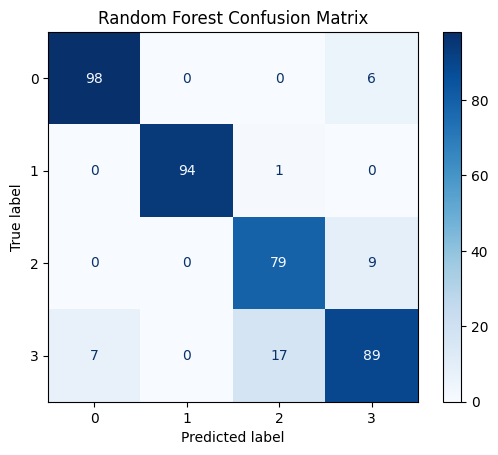

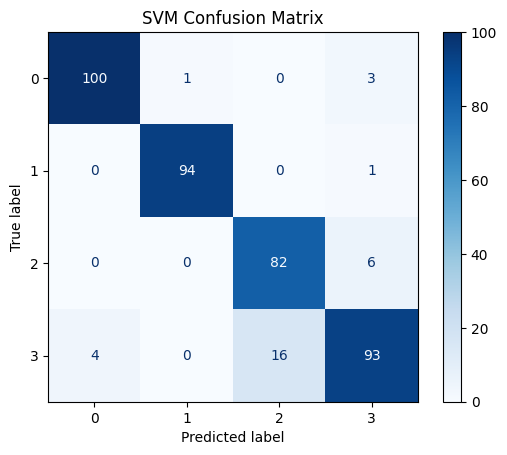

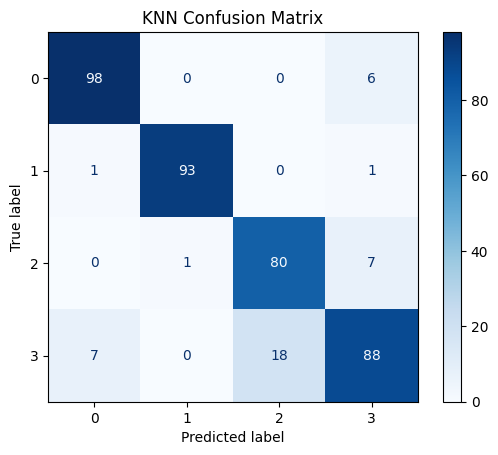

In [18]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

# Plot confusion matrix for Random Forest
plot_confusion_matrix(y_test, rf.predict(X_test), "Random Forest Confusion Matrix")
# Plot confusion matrix for SVM
plot_confusion_matrix(y_test, svm.predict(X_test), "SVM Confusion Matrix")
# Plot confusion matrix for KNN
plot_confusion_matrix(y_test, knn.predict(X_test), "KNN Confusion Matrix")